## Name: Shardul Gore
## Roll no: R016

## Objective 1:
To build, train, and evaluate RNN and LSTM models to predict the next day's mean temperature using historical daily climate data from Delhi.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM

In [2]:
df = pd.read_csv('/content/DailyDelhiClimateTest.csv')

In [3]:
df.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
5,2017-01-06,19.318182,79.318182,8.681818,1011.772727
6,2017-01-07,14.708333,95.833333,10.041667,1011.375000
7,2017-01-08,15.684211,83.526316,1.950000,1015.550000
8,2017-01-09,14.571429,80.809524,6.542857,1015.952381
9,2017-01-10,12.111111,71.944444,9.361111,1016.888889


## Part A – Data Preparation

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df['date']

,date
0,2017-01-01
1,2017-01-02
2,2017-01-03
3,2017-01-04
4,2017-01-05
...,...
109,2017-04-20
110,2017-04-21
111,2017-04-22
112,2017-04-23


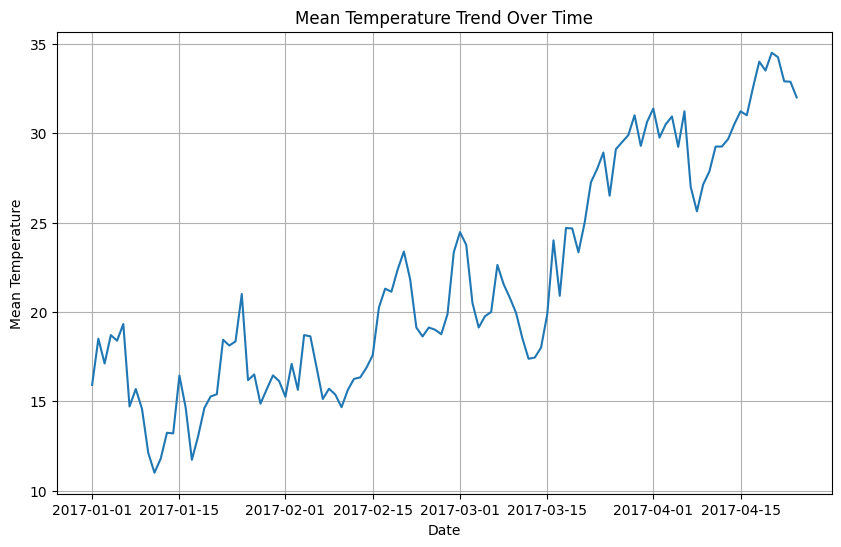

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['meantemp'])
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.title('Mean Temperature Trend Over Time')
plt.grid(True)
plt.show()

In [7]:
print(df.isnull().sum())

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


No null Values

In [8]:
scaler = MinMaxScaler() # standardization

In [9]:
df['meantemp_normalized'] = scaler.fit_transform(df[['meantemp']])

print(df.head())

        date   meantemp   humidity  wind_speed  meanpressure  \
0 2017-01-01  15.913043  85.869565    2.743478     59.000000   
1 2017-01-02  18.500000  77.222222    2.894444   1018.277778   
2 2017-01-03  17.111111  81.888889    4.016667   1018.333333   
3 2017-01-04  18.700000  70.050000    4.545000   1015.700000   
4 2017-01-05  18.388889  74.944444    3.300000   1014.333333   

   meantemp_normalized  
0             0.209066  
1             0.319149  
2             0.260047  
3             0.327660  
4             0.314421  


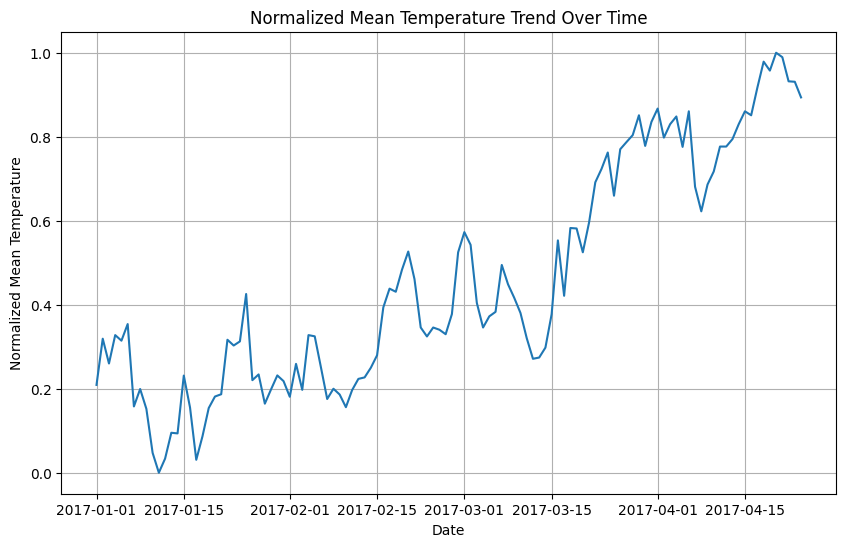

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['meantemp_normalized'])
plt.xlabel('Date')
plt.ylabel('Normalized Mean Temperature')
plt.title('Normalized Mean Temperature Trend Over Time')
plt.grid(True)
plt.show()

In [11]:
def prepare_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [12]:
seq_length = 7  # Use the last 7 days to predict the 8th day
X, y = prepare_sequences(df['meantemp_normalized'].values, seq_length)

print("Shape of input sequences:", X.shape)
print("Shape of output sequences:", y.shape)

Shape of input sequences: (106, 7)
Shape of output sequences: (106,)


## Part B – Model Building & Training

In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape the input data for Keras
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((84, 7, 1), (22, 7, 1), (84,), (22,))

In [15]:
model = Sequential()
model.add(SimpleRNN(units=50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(units=50, activation='tanh'))
model.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(optimizer='adam', loss='mse')

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 7, 50)               │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.9045
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1927
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1905
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0322
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0884
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0658
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0158
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0322
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0373
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0142


In [19]:
# Evaluation of model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - loss: 0.0155
Test Loss: 0.015498981811106205


In [20]:
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(units=50, activation='tanh'))
lstm_model.add(Dense(units=1))

In [21]:
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 50)               │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - loss: 0.2516 - val_loss: 0.2756
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1645 - val_loss: 0.1628
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1028 - val_loss: 0.0667
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0391 - val_loss: 0.0141
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0205 - val_loss: 0.0211
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0371 - val_loss: 0.0196
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0315 - val_loss: 0.0109
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0186 - val_loss: 0.0155
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0177 - val_loss: 0.0239
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0187 - val_loss: 0.0259


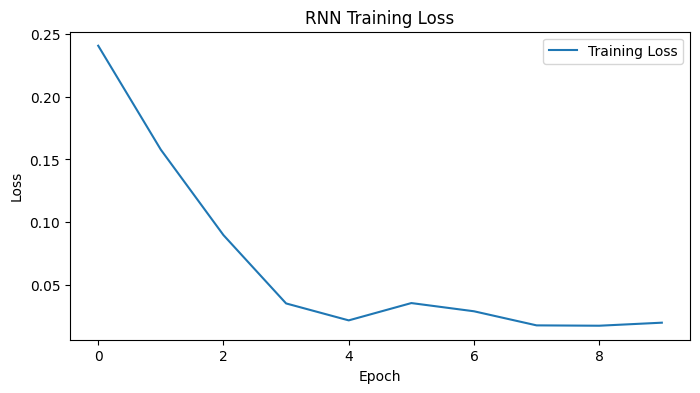

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training Loss')
plt.legend()
plt.show()

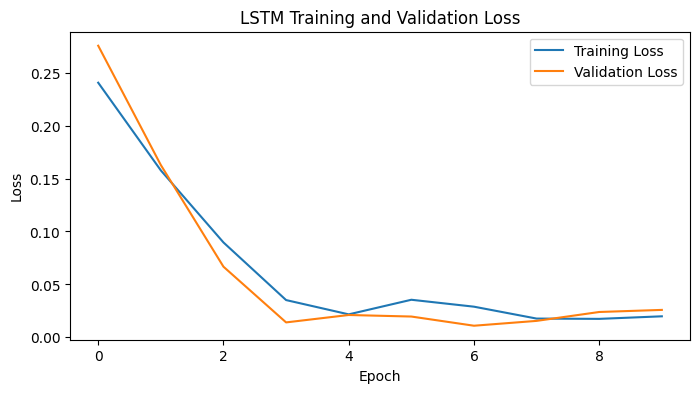

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()

## Part C – Results & Analysis

In [25]:
rnn_predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


In [26]:
lstm_predictions = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


In [27]:
# inversing trasnformation to get actual predictions
rnn_predictions_actual = scaler.inverse_transform(rnn_predictions)
lstm_predictions_actual = scaler.inverse_transform(lstm_predictions)

In [28]:
last_sequence = df['meantemp_normalized'].values[-seq_length:]
last_sequence = np.reshape(last_sequence, (1, seq_length, 1))

In [29]:
rnn_future_predictions = []
lstm_future_predictions = []
for _ in range(7):
    # RNN
    rnn_next_pred = model.predict(last_sequence)
    rnn_future_predictions.append(scaler.inverse_transform(rnn_next_pred)[0][0])
    last_sequence = np.concatenate((last_sequence[:,1:,:], rnn_next_pred.reshape(1,1,1)),axis=1)

    # LSTM
    lstm_next_pred = lstm_model.predict(last_sequence)
    lstm_future_predictions.append(scaler.inverse_transform(lstm_next_pred)[0][0])
    last_sequence = np.concatenate((last_sequence[:,1:,:], lstm_next_pred.reshape(1,1,1)),axis=1)

print("Next 7 days temperature predictions (SimpleRNN):", rnn_future_predictions)
print("Next 7 days temperature predictions (LSTM):", lstm_future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Next 7 days temperature predictions (SimpleRNN): [np.float32(28.902409), np.float32(27.570086), np.float32(26.856783), np.float32(26.099669), np.float32(25.084118), np.float32(24.313387), np.float32(23.817074)]
Next 7 days temperature predictions (LSTM): [np.float32(28.797348), np.float32(27.726368), np.float32(26.38987), np.float32(25.076012), np.float32(24.337784), np.float32(23.667376), np.float32(23.072886)]


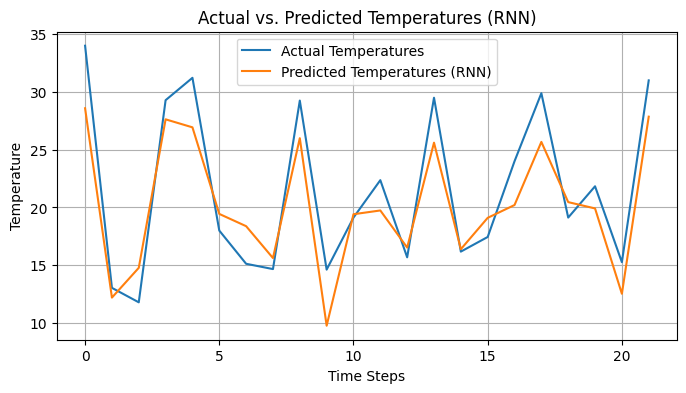

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(y_test_actual, label='Actual Temperatures')
plt.plot(rnn_predictions_actual, label='Predicted Temperatures (RNN)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.title('Actual vs. Predicted Temperatures (RNN)')
plt.legend()
plt.grid(True)
plt.show()


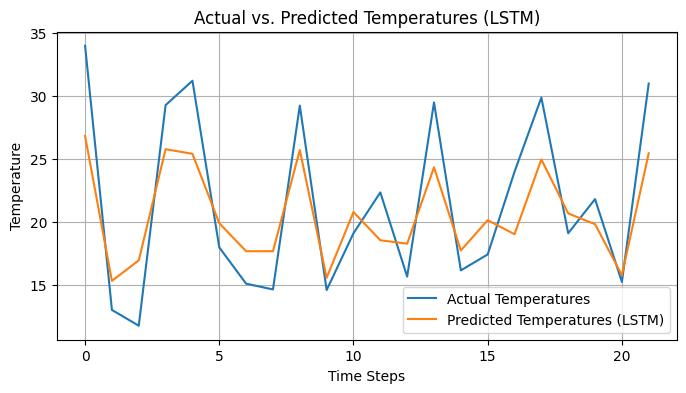

In [30]:
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.plot(y_test_actual, label='Actual Temperatures')
plt.plot(lstm_predictions_actual, label='Predicted Temperatures (LSTM)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.title('Actual vs. Predicted Temperatures (LSTM)')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions_actual))
print(f"RNN RMSE: {rnn_rmse}")

RNN RMSE: 2.9256301756486947


In [33]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions_actual))
print(f"LSTM RMSE: {lstm_rmse}")

LSTM RMSE: 3.7451355382701372


In [34]:
if rnn_rmse < lstm_rmse:
    print("RNN model performed better based on RMSE.")
elif lstm_rmse < rnn_rmse:
    print("LSTM model performed better based on RMSE.")
else:
    print("Both models have the same RMSE.")

RNN model performed better based on RMSE.



Based on the printed RMSE values, the model with the lower RMSE performed better. RNN is performing better than LST in this case